# Strategic Economic Analysis: Market Trends and State-Level Labor Dynamics



This project automates the retrieval and analysis of real-time economic indicators from the Federal Reserve Economic Data (FRED) API. By integrating disparate financial and labour datasets, I conducted a comparative analysis of market performance (S&P 500) against regional unemployment trends in the U.S. to identify macroeconomic patterns.

**Key skills showcased:** Python, API integration (`fredapi`), Time-Series Data Wrangling (`pandas`), Data Visualisation (`Plotly`, `Matplotlib`), and Exploratory Data Analysis (EDA).

Setup Note: This notebook requires a FRED API Key. To run this, get a free key from FRED St. Louis and add it to your Colab Secrets as `fredapi_key`.

In [1]:
!pip install fredapi > /dev/null

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

plt.style.use('fivethirtyeight')
# pd.set_option('max_columns', 500)
colour_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]

from fredapi import Fred
import os
from dotenv import load_dotenv

load_dotenv()
fredapi_key = os.getenv('FRED_API_KEY')

## 1. Data Acquisition Strategy

To ensure data integrity, I utilized the `fredapi` libary to interface directly with the St. Louis Fed's ecosystem.

In [3]:
fred = Fred(api_key=fredapi_key)

**Selection criteria:** I filtered for 'Seasonally Adjusted' series to eliminate predictable calendar noise (e.g. holiday hiring surges).

**Optimisation:** I implemented a search-and-rank function to identify the most 'popular' data series, ensuring the analysis focuses on high-impact economic drivers.



In [4]:
sp_search = fred.search('S&P', order_by="popularity")
sp_search.head()

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
BAMLH0A0HYM2,BAMLH0A0HYM2,2026-03-09,2026-03-09,ICE BofA US High Yield Index Option-Adjusted S...,1996-12-31,2026-03-05,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 08:43:46-06:00,100,The ICE BofA Option-Adjusted Spreads (OASs) ar...
SP500,SP500,2026-03-09,2026-03-09,S&P 500,2016-03-07,2026-03-06,"Daily, Close",D,Index,Index,Not Seasonally Adjusted,NSA,2026-03-06 19:01:50-06:00,91,The observations for the S&P 500 represent the...
BAMLC0A0CM,BAMLC0A0CM,2026-03-09,2026-03-09,ICE BofA US Corporate Index Option-Adjusted Sp...,1996-12-31,2026-03-05,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 08:44:52-06:00,86,The ICE BofA Option-Adjusted Spreads (OASs) ar...
BAMLH0A0HYM2EY,BAMLH0A0HYM2EY,2026-03-09,2026-03-09,ICE BofA US High Yield Index Effective Yield,1996-12-31,2026-03-05,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-03-06 08:43:41-06:00,85,This data represents the effective yield of th...
CSUSHPINSA,CSUSHPINSA,2026-03-09,2026-03-09,S&P Cotality Case-Shiller U.S. National Home P...,1987-01-01,2025-12-01,Monthly,M,Index Jan 2000=100,Index Jan 2000=100,Not Seasonally Adjusted,NSA,2026-02-24 08:15:26-06:00,85,"For more information regarding the index, plea..."


## 2. Benchmark Analysis: The S&P 500 Index

Before diving into labour data, I established a baseline using the S&P 500. This acts as a proxy for investor sentiment and overall corporate health.

**Analytical insight:** There are 'shocks' in the timeline. By plotting long-term historical data, we can correalte specific market dips with subsequent changes in the labour market, testing the theory of 'lagging indicators'.

<Axes: title={'center': 'S&P 500'}>

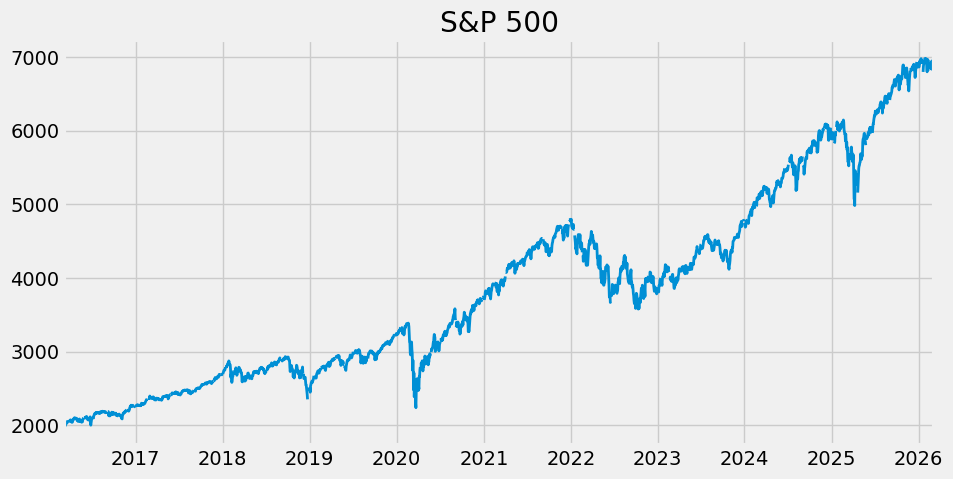

In [5]:
sp500 = fred.get_series(series_id='SP500')
sp500.plot(figsize=(10, 5), title='S&P 500', lw=2)

## 3. Multi-State Labour Market Comparison

The challenge in regional analysis is 'Data Fragmentation'. Each state has its own series ID (e.g. 'NYUR' for New York, 'TXUR' for Texas).

Data engineering approach: I performed a many-to-one join, algining disparate time-series into a single master dataframe, `unemp_states`. I then applied a mapping function to rename cryptic API IDs into human-readable labels, facilitating stakeholder interpretation.

In [6]:
unemp_df = fred.search('unemployment rate state', filter=('frequency', 'Monthly'))
unemp_df = unemp_df.query('seasonal_adjustment == "Seasonally Adjusted" and units == "Percent"')
unemp_df = unemp_df.loc[unemp_df['title'].str.contains('Unemployment Rate')] \
            .loc[unemp_df['id'].str.contains('UR')]

In [7]:
unemp_df.head()

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
CAUR,CAUR,2026-03-09,2026-03-09,Unemployment Rate in California,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:48:30-06:00,66,None
TXUR,TXUR,2026-03-09,2026-03-09,Unemployment Rate in Texas,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:47:48-06:00,57,None
NYUR,NYUR,2026-03-09,2026-03-09,Unemployment Rate in New York,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:47:51-06:00,56,None
FLUR,FLUR,2026-03-09,2026-03-09,Unemployment Rate in Florida,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:47:58-06:00,51,None
ALUR,ALUR,2026-03-09,2026-03-09,Unemployment Rate in Alabama,1976-01-01,2025-12-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-01-28 09:48:40-06:00,48,None


In [8]:
all_results = []

for myid in unemp_df.index:
    results = fred.get_series(myid)
    results = results.to_frame(name=myid)  # make results into a  df
    all_results.append(results)

unemp_states = pd.concat(all_results, axis=1)

In [9]:
id_to_state = unemp_df['title'].str.replace('Unemployment Rate in ', '').to_dict()
unemp_states.columns = [id_to_state.get(c, c) for c in unemp_states.columns.str.strip()]

unemp_states.head()

,California,Texas,New York,Florida,Alabama,Illinois,Georgia,Michigan,Pennsylvania,Virginia,...,Kansas,Arkansas,Utah,New Hampshire,Oklahoma,New Mexico,South Dakota,Connecticut,Vermont,Nebraska
1976-01-01,9.2,5.8,10.3,9.6,6.7,6.6,8.4,9.9,8.1,6.0,...,4.2,7.3,5.8,6.5,5.8,8.6,3.3,9.7,8.5,3.2
1976-02-01,9.2,5.8,10.3,9.7,6.6,6.6,8.4,9.9,8.1,6.0,...,4.2,7.3,5.9,6.5,5.8,8.6,3.3,9.7,8.5,3.2
1976-03-01,9.1,5.9,10.2,9.6,6.6,6.6,8.3,9.9,8.1,6.0,...,4.2,7.3,5.8,6.5,5.8,8.6,3.3,9.7,8.6,3.2
1976-04-01,9.0,5.9,10.2,9.5,6.5,6.6,8.2,9.8,8.1,5.9,...,4.2,7.2,5.8,6.5,5.7,8.6,3.2,9.6,8.5,3.1
1976-05-01,8.9,6.0,10.2,9.3,6.4,6.6,8.1,9.6,8.1,5.8,...,4.2,7.1,5.7,6.5,5.7,8.6,3.1,9.4,8.5,3.0


### Findings: Regional Resilience vs National Trends

By visualising unemployment rates across California, New York and Florida, we observe distinct patterns.


*   **Observation:** New York and California often show higher volatility during financial crises compared to Texas.
*   **Conclusion:** This suggests that industry composition (Finance/Tech vs Energy/Agriculture) plays a critical role in how states weather economic downturns.



In [10]:
# Plot States Unemployment Rate
px.line(unemp_states)

### 3.1 Quantifying the intensity: The Pandemic Shock Delta

While time-series visualisations effectively track the trajectory of economic recovery, they can sometimes obscure the absolute magnitude of a sudden shock. In this section, I calculate the **Pandemic Shock Delta**, defined as the net percentage-point increase in unemployment between February 2020 (the final-pre-lockdown month) and May 2020 (the peak of the initial contraction). This serves as a primary indicator of regional economic fragility.

In [11]:
# Calculate the net increase from Feb 2020 to May 2020
pandemic_delta = unemp_states.loc['2020-05-01'] - unemp_states.loc['2020-02-01']
pandemic_delta = pandemic_delta.sort_values(ascending=False).dropna()

# Visualize the Top 10 hardest-hit states
import plotly.express as px
fig = px.bar(pandemic_delta.head(10),
             title='The Pandemic Shock: Largest Net Increases in Unemployment (Feb-May 2020)',
             labels={'value': 'Unemployment Rate Increase (%)', 'index': 'State'},
             color=pandemic_delta.head(10).values,
             color_continuous_scale='Reds')
fig.show()

**Analytical Insight:**
The resulting bar chart reveals a stark disparity in economic resilience across the U.S.


*   States like Nevada & Hawaii experienced deltas significantly higher than the national average. This is a direct consequence of their economic 'over-weighing' in the leisure and hospitality sectors, which faced total cessation during the lockdown period
*   Conversely, states with a larger share of agricultural, government, or remote-capable 'knowledge work' sectors saw a more muted 'Delta'

This ranking was achieved through vectorised subtraction across the dataframe's columns. This approach is significantly more efficient than iterating through rows and allows for instant scalability as more state series are added to the pipeline.



## 4. Cross-Sectional Analysis: Pull May 2020 Unemployment Rate per State

While time-series plots are vital for tracking long-term trends, cross-sectional snapshots allow us to quantify the exact depth of economic shocks at a single point in time. I isolated the data for **May 2020**, at the height of the pandemic labour market disruption, to perform a comparative resilience analysis across most U.S. states.

This section utilises Pandas `.loc` slicing on a `DateTimeIndex` to extract a single row of data across 40+ columns, demonstrating efficiency in high-cardinality data retrieval.

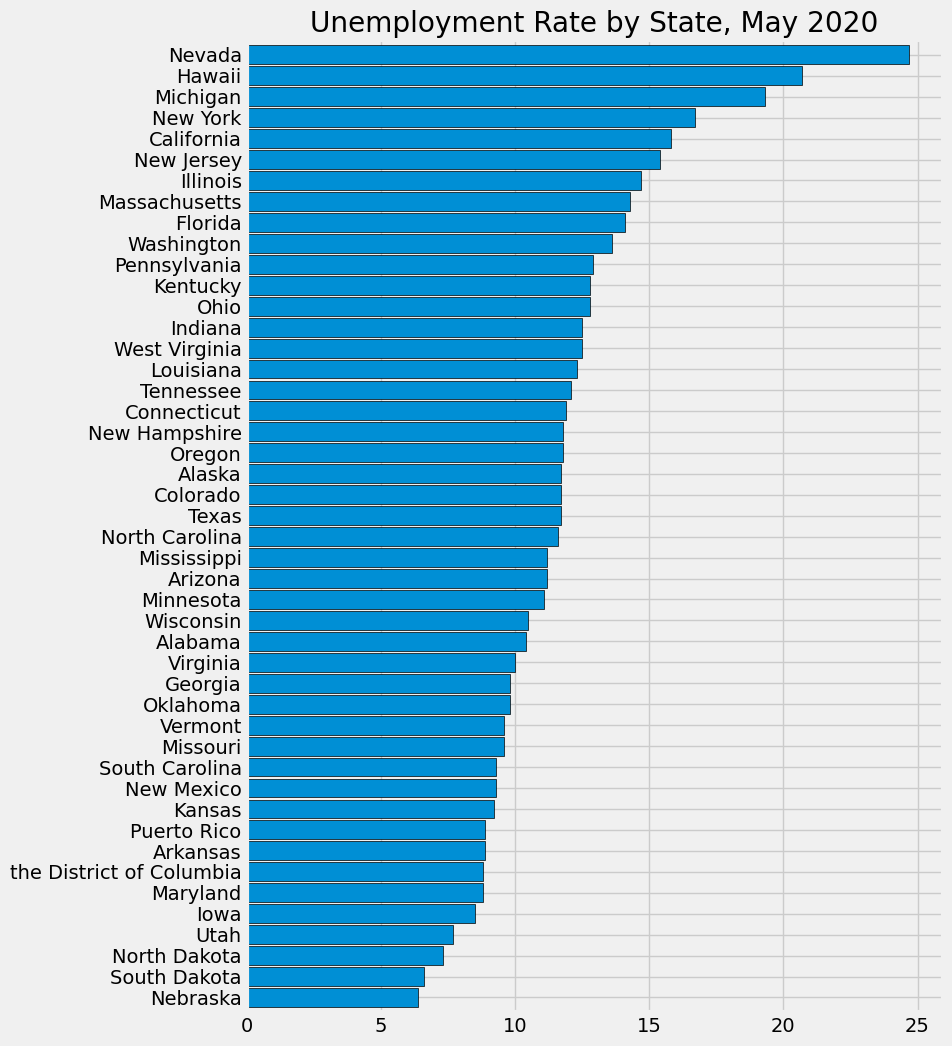

In [12]:
ax = unemp_states.loc[unemp_states.index == "2020-05-01"].T \
    .sort_values('2020-05-01') \
    .plot(kind='barh', figsize=(8,12), width=0.9, edgecolor='black',
         title='Unemployment Rate by State, May 2020')
ax.legend().remove()
plt.show()

**Findings & Patterns:**
*  **Sectoral Sensitivity:** States with a high concentration of tourism and face-to-face services (e.g. Nevada and Hawaii) show the most drastic spikes in unemployment, highlighting a structural vulnaerability to "mobility shocks".
*  **The Pandemic Delta:** The variance between states in May 2020 was at an all-time high. This suggests that during extreme volatility, national averages (the "macro" view) often mask critical "micro" regional/state-level crises

## 5. Secondary Labour Metric: Pulling the Labour Force Participation Rate

The unemployment rate alone can be a deceptive metric as it only counts those actively seeking work. To gain a holistic view of labour market health, we can pull the **Labour Force Participation Rate**.

**The Goal:** By fetching this series from the FRED API, we can determine if a "low unemployment rate" is due to strong hiring or simply a shrinking labour force (people giving up on job-finding and dropping out). From an economics perspective, this distinction is important for identifying the "hidden slack" in the economy.

In [13]:
part_df = fred.search('participation rate state', filter=('frequency', 'Monthly'))
part_df = part_df.query('seasonal_adjustment == "Seasonally Adjusted" and units == "Percent"')

part_df = part_df.loc[part_df['title'].str.contains('Labor Force Participation Rate')] \
    .loc[part_df['id'].str.contains('LBSSA')]

In [14]:
all_results = []

for myid in part_df.index:
    results = fred.get_series(myid)
    results = results.to_frame(name=myid)  # make results into a  df
    all_results.append(results)

part_states = pd.concat(all_results, axis=1)

In [15]:
part_id_to_state = part_df['title'].str.replace('Labor Force Participation Rate for ', '').to_dict()
part_states.columns = [part_id_to_state.get(c,c) for c in part_states.columns]

part_states.head()

,Georgia,Alabama,Louisiana,Mississippi,California,Wisconsin,Florida,Texas,Ohio,Michigan,...,Nebraska,Missouri,Rhode Island,Wyoming,Kansas,Idaho,South Dakota,North Dakota,Montana,Delaware
1976-01-01,63.8,57.1,56.9,58.8,62.5,65.6,55.8,63.7,61.7,61.6,...,64.7,60.5,63.8,65.3,65.2,63.1,64.8,62.7,62.5,62.7
1976-02-01,63.6,56.9,56.7,58.6,62.4,65.5,55.6,63.5,61.6,61.5,...,64.6,60.4,63.7,65.0,65.1,62.9,64.7,62.5,62.4,62.6
1976-03-01,63.5,56.8,56.5,58.5,62.2,65.5,55.5,63.3,61.6,61.5,...,64.6,60.3,63.7,64.8,65.0,62.8,64.6,62.4,62.3,62.6
1976-04-01,63.6,56.8,56.5,58.5,62.2,65.5,55.4,63.4,61.6,61.6,...,64.6,60.4,63.7,65.0,65.1,62.8,64.6,62.5,62.1,62.5
1976-05-01,63.6,56.8,56.5,58.5,62.2,65.6,55.3,63.6,61.5,61.7,...,64.6,60.6,63.7,65.2,65.2,62.9,64.6,62.6,62.0,62.5


## 6. Unemployment vs. Participation

I have plotted the Unemployment Rate and the Labour Force Participation Rate on a shared timeline to observe the cyclicality of labour. Typically, we expect an inverse relationship; however, during structural shifts (like the 2008 or 2020 crises), both can drop simultaneously, indicating a "participation cliff" that complicates the recovery path.

In [16]:
# fix DC column name
unemp_states = unemp_states.rename(columns={'the District of Columbia':'District Of Columbia'})

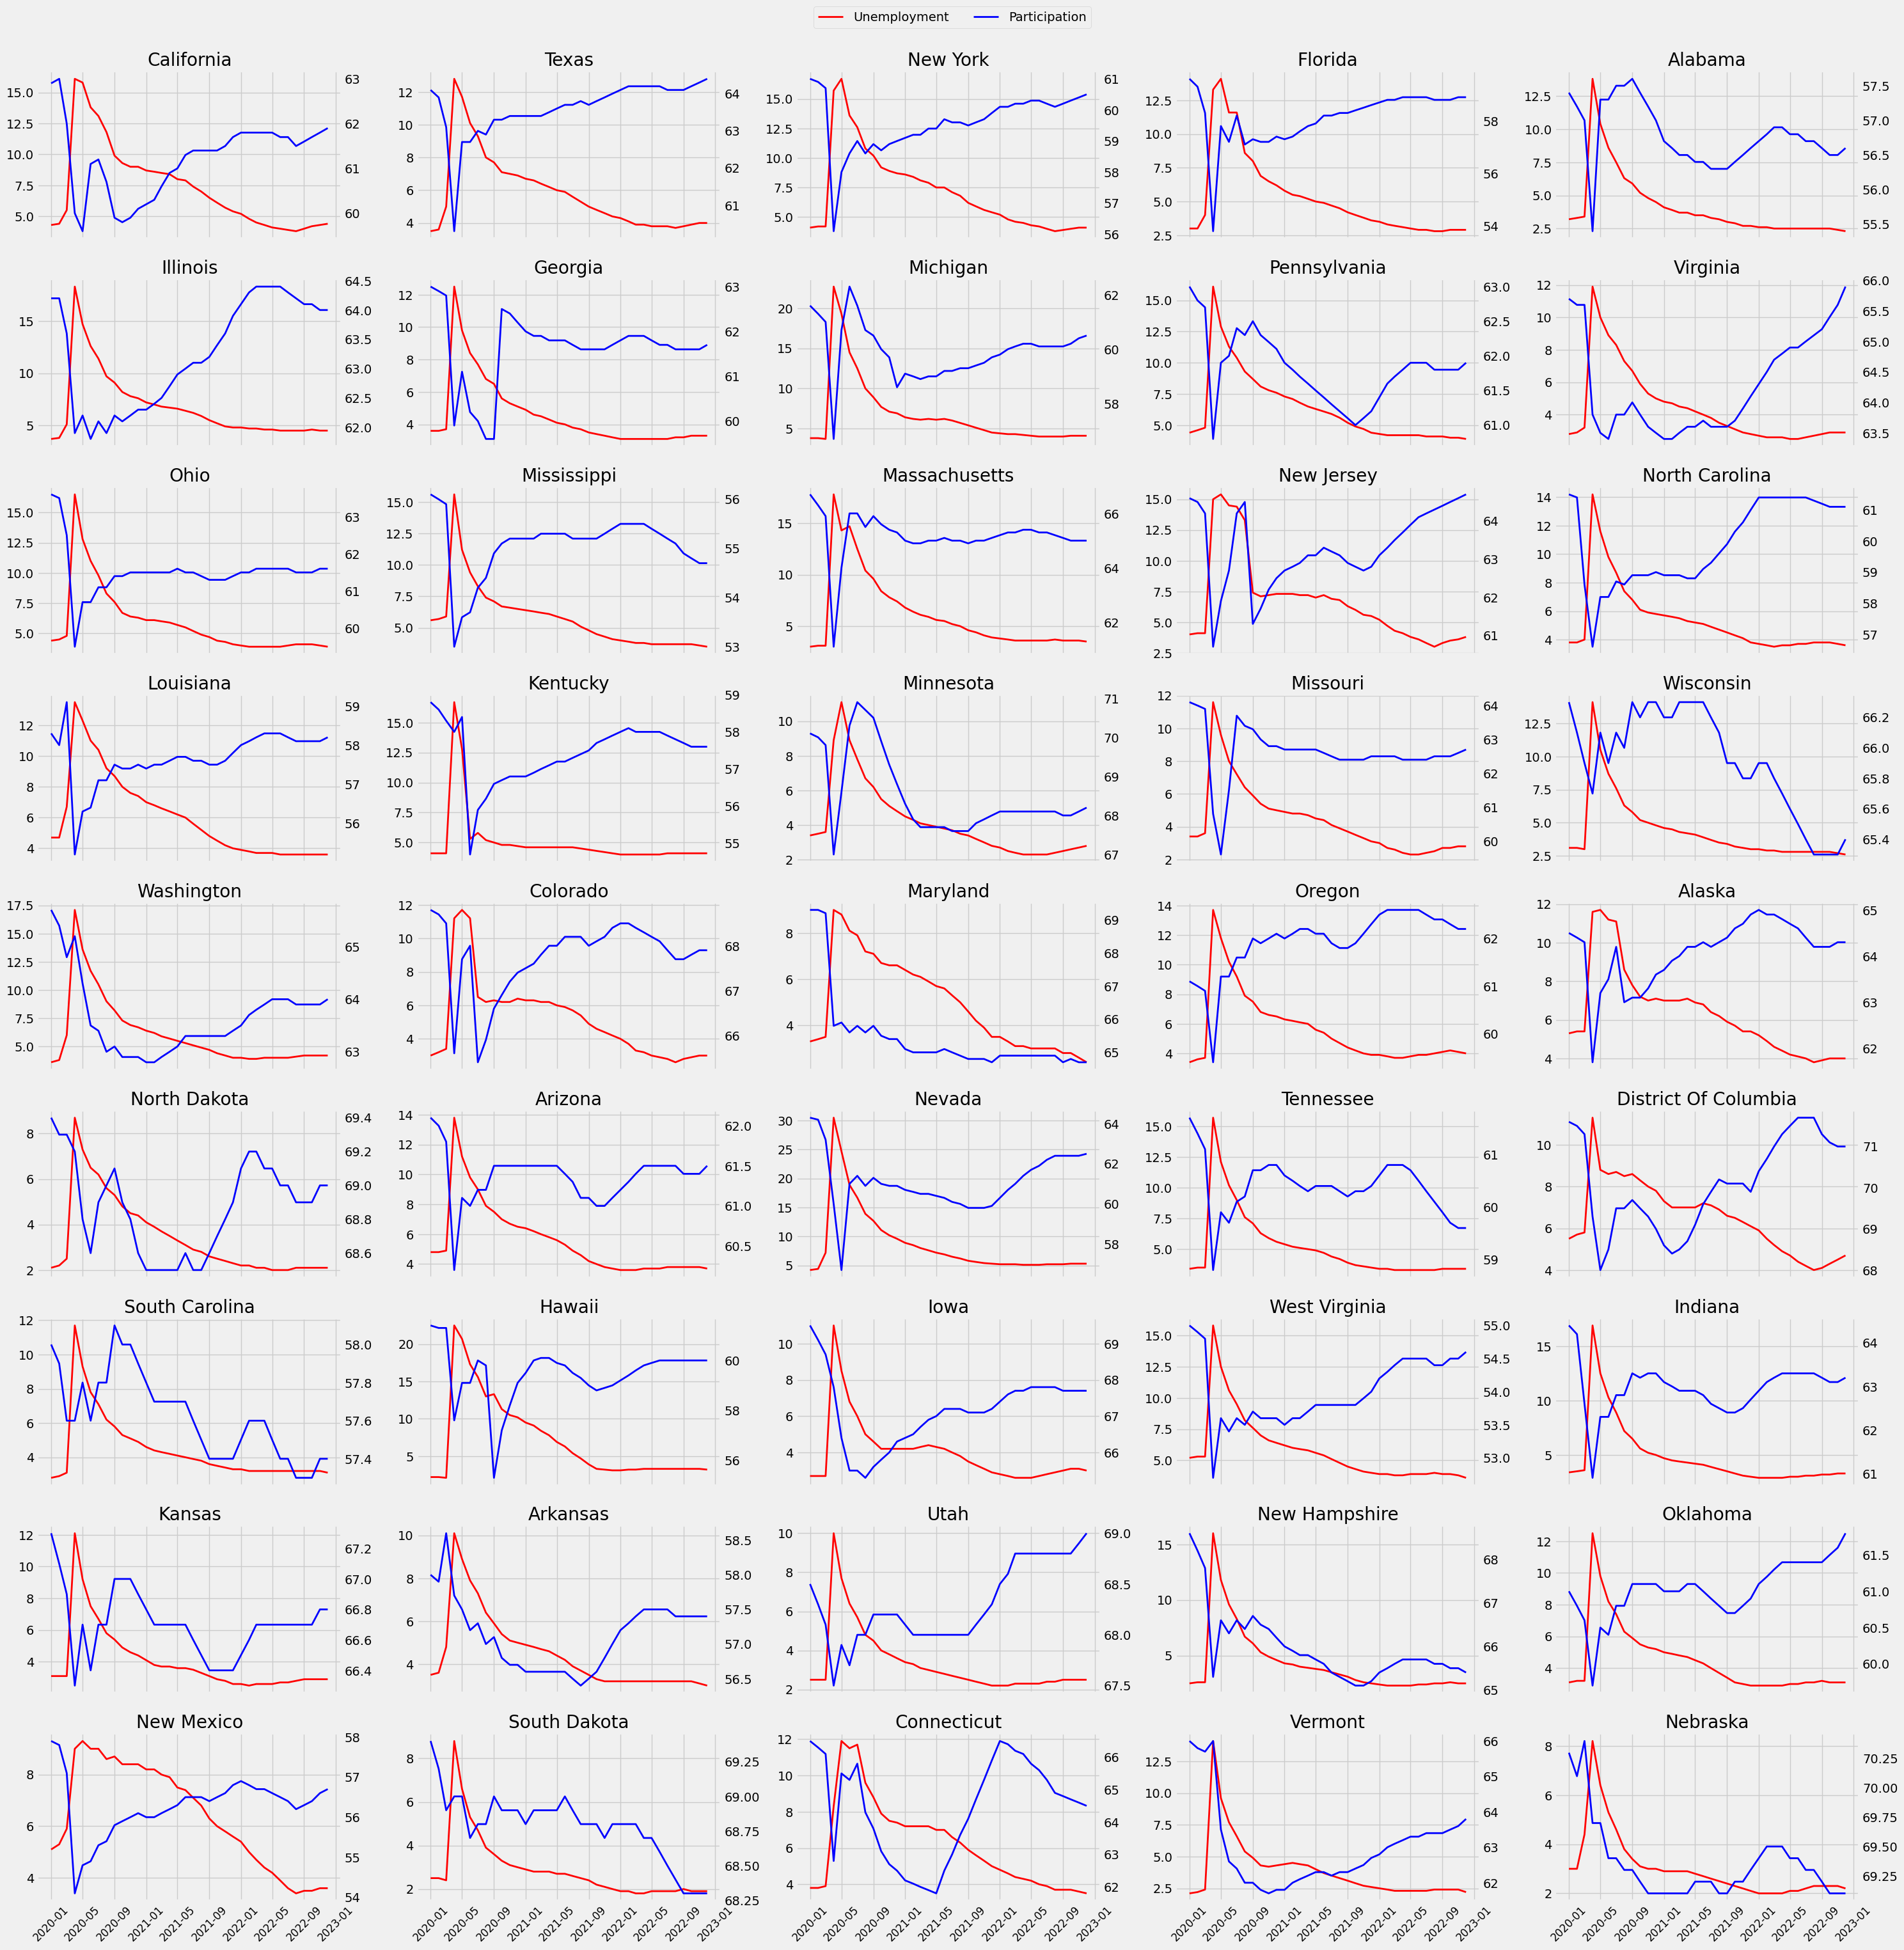

In [17]:
fig, axs = plt.subplots(9, 5, figsize=(30, 30), sharex=True)
axs = axs.flatten()

i = 0
for state in unemp_states.columns:
    if state == 'Puerto Rico':
      continue
    ax = axs[i]
    ax2 = ax.twinx()

    u_data = unemp_states.loc['2020':'2022', state]
    p_data = part_states.loc['2020':'2022', state]

    # Plot Unemployment on the left axis
    ax.plot(u_data.index, u_data.values, label='Unemployment', color='red', linewidth=2)

    # Plot Participation on the right axis
    ax2.plot(p_data.index, p_data.values, label='Participation', color='blue', linewidth=2)

    ax2.grid(False)
    ax.set_title(state)
    i += 1

for ax in axs.flat:
    ax.tick_params(axis='x', rotation=45, labelsize=12)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

fig.legend(lines + lines2, ['Unemployment', 'Participation'],
           loc='upper center',
           ncol=2,
           bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()

**Analysis of the Subplots:**
*  While unemployment recovered briskly after April-May 2020, participation plummeted and has remained persistently below pre-pandemic levels.
*  This divergence suggests that the "post-pandemic labour shortage" was driven less by a lack of jobs and more by a structural shift in labour supply, likely due to early retirements and changing household priorities.

## 7. Labour Dynamics vs. S&P 500 (The Lag Effect)

This section integrates our labour findings with the S&P 50 data established at the start.

**Observations on Macroeconomic Lag:**
1. Market foresight: the S&P 500 is a leading indicator. It bottomed in March 2020 and was in a full "bull market" by the summer, months before the labour market showed significant improvement.
2. Labour inertia: Unemployment is a **lagging indicator**. Corporate hiring cycles move slowly, so by the time unemployment hit its peak in mid-2020, the stock market had already "priced in" the recovery
3. Visualising these together shows that capital markets respond in stimulus and future expectations (the "Fed Response"), while labour metrics respond to current operational reality.

## 8. Project Summary

This project successfully developed an end-to-end pipeline to monitor unemployment in the economy, proving that regional resilience is dictated by industry composition and that financial markets lead labour recoveres by a significant margin.

**Technical skills showcased:**
*  **Data engineering:** Automating the ingestion of 40+ series via the `fredapi`
*  **Wrangling:** Using dictionary mapping to resolve the "Data Fragmentation of crytic series IDs into actionable state-level insights
*  **Synthesis:** Combining financial (S&P 500) and labour (unemployment/labour force participation) data to provide a multi-dimensional economic narrative.

**Future directions & scalability:**
The modular architecture of this project is designed for global adaptaion. As a next step, I plan to integrate the *SingStat API* (Singapore Department of Statistics) to perform a comparative analysis of Singapore's labour resilience against these U.S. benchmarks.